In [1]:
from scipy.optimize import curve_fit as cft
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import astropy
import scipy.integrate as integrate
import pandas
from astropy.cosmology import FlatLambdaCDM
from IPython.display import display, Math

In [2]:
def sampler(i):

    # Importing constants 

    Planck = astropy.cosmology.realizations.Planck18

    T_CMB = Planck.Tcmb0  # Temperature of the CMB
    H_0 = Planck.H0  # Current Hubble constant
    Omega_m = Planck.Om0  # Matter density parameter
    Omega_lambda = Planck.Ode0  # Dark energy density parameter
    c = astropy.constants.c.to('km/s')  # Speed of light in km/s
    sigma_T = astropy.constants.sigma_T.to('km2')  # Thomson scattering cross-section in km^2
    Omega_b = Planck.Ob0  # Baryon density parameter


    # Setting parameters

    z = 8  # Redshift of the quasar bubbles 
    f_H = 0.21  # fraction of neutral hydrogen at z = 8


    # Input Data

    data = pandas.read_csv('Data/u_0.0pc_noise.csv')

    Ang_deg = np.array([data['radius_y'][0]])  # In arcmins
    amp = np.array([data['amp_y'][0]]) * 1e-6  # Amplitude in K


    # Importing the Flat Lambda CDM model

    cosmo = FlatLambdaCDM(H0=H_0.value, Om0=Omega_m, Tcmb0= T_CMB.value)


    # Obtaining the angular diameter distance at z

    D_A = cosmo.angular_diameter_distance(z)  # units: Mpc/radian


    # Defining a function that converts from our angular distance to proper distance

    def AngToDist(Ang_deg= Ang_deg):
        
        Ang_rad = Ang_deg * np.pi / (180 * 60)  # Convert arcmins to radians
        Distance = D_A * Ang_rad  # Convert angular distance to actual distance

        return Distance


    # Calculating the actual radii of the bubbles and y

    Radius = AngToDist(Ang_deg)  # in Mpc

    y = amp / T_CMB.value  


    # Calculating n_e and n_H

    n_e = y * 3 * np.sqrt(1+z) / (sigma_T * 0.001 * 2 * Radius.to('km'))

    n_H = n_e / (1 - f_H)  # Assuming all electrons are from ionized hydrogen


    # Defining the model using the Stromgren sphere approximation

    def model(theta, n_H): 
        N_tilde, t_tilde = theta
        return (((3)/(4*np.pi*n_H))**(1/3)) * (N_tilde * t_tilde)**(1/3) * (1e58)**(1/3) * (1e7 * 3.156e7)**(1/3)  


    # Setting up initial, lower and upper bounds for the parameters

    N_ini = 50  
    N_min = 0.   
    N_max = 100

    t_ini = 5
    t_min = 0.
    t_max = 10


    # Calculating error in the diameter

    Ang_err = np.array([0.5] * len(Ang_deg))  # Error in determining the angular diameter in arcmins
    Radius_err = Ang_err * np.pi / (180 * 60) * D_A  # Convert angular error to actual diameter error


    # Defining the log-likelihood function

    def lnlike(theta, x, y, y_err):
        return -0.5 * np.sum(((y - model(theta, x)) / y_err) ** 2)

    # Defining the log-prior function

    def lnprior(theta):
        N_tilde, t_tilde = theta
        if N_tilde < N_min or t_tilde < t_min or N_tilde > N_max  or t_tilde > t_max:
            return -np.inf
        return 0.0

    # Defining the log-posterior function

    def lnprob(theta, x, y, yerr):
        lp = lnprior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + lnlike(theta, x, y, yerr)



    # Setting initial values for the parameters
    initial = [N_ini, t_ini]  

    # Setting up the MCMC sampler
    ndim = len(initial)
    nwalkers = 7 * ndim    # Preferentially 3-5 times the number of dimensions (minimum 2 times the number of dimensions)
    n_burn = 200
    n_steps = 10000

    # Initializing the sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(n_H.to('km-3').value, Radius.to('km').value, Radius_err.to('km').value))

    # Adding little variation to the initial positions
    p0 = []
    for i in range(nwalkers):
        pos = [N_ini, t_ini]  # Start with the initial values
        pos[0] = pos[0] + 1e-4 * pos[0] * np.random.random(1)[0]  # Adding a small random variation to N_dot
        pos[1] = pos[1] + 1e-4 * pos[1] * np.random.random(1)[0]  # Adding a small random variation to t_Q
        p0.append(pos)   


    # Running the MCMC sampler
    
    # Burn-in phase
    print("Running burn-in phase...")
    sampler.reset()
    state = sampler.run_mcmc(p0, n_burn, progress=True)
    sampler.reset()

    # Main sampling phase
    print("Running main sampling phase...")
    pos, prob, state = sampler.run_mcmc(state, n_steps, progress=True)

    # Extracting the samples
    samples = sampler.get_chain(flat=True)      # Flatten the chain to get all samples in a single array

    return samples


    # Printing the results

    # med_params = np.median(samples, axis=0)

    # print("N_tilde:", med_params[0], "; t_tilde:", med_params[1])

    # mcmc = np.percentile(samples[:, 0], [16, 50, 84], axis=0)
    # q = np.diff(mcmc)
    # print("N_tilde_err: -", q[0], "to +", q[1])

    # mcmc = np.percentile(samples[:, 1], [16, 50, 84], axis=0)
    # q = np.diff(mcmc)
    # print("t_tilde_err: -", q[0], "to +", q[1])


    # Calculating the radii using the estimated parameters 

    # med_params = np.median(samples, axis=0)  # The median of the parameters 
    # print(model(med_params, n_H).to('Mpc'))  # The estimated radius in Mpc


    # # Plotting a corner plot of the samples along with the quantiles

    # fig = corner.corner(samples, labels=["N_tilde", "t_tilde"],  quantiles=[0.16, 0.5, 0.84], show_titles=True, plot_datapoints=True, smooth=1)
    # plt.show()

In [3]:
N_tilde = []
t_tilde = []

for i in range(0,8):
    samples = sampler(i)

    med_params = np.median(samples, axis=0)
    N_tilde.append(med_params[0])
    t_tilde.append(med_params[1])

N_dot = np.array(N_tilde) * 1e58  
t_Q = np.array(t_tilde) * 1e7 * 3.156e7

# Sorting the arrays based on t_Q
sort_indices = np.argsort(t_Q)
t_Q = t_Q[sort_indices]
N_dot = N_dot[sort_indices]


Running burn-in phase...


100%|██████████| 200/200 [00:00<00:00, 1834.57it/s]


Running main sampling phase...


100%|██████████| 10000/10000 [00:05<00:00, 1818.92it/s]


Running burn-in phase...


...

100%|██████████| 10000/10000 [00:05<00:00, 1845.67it/s]


Running burn-in phase...


100%|██████████| 200/200 [00:00<00:00, 1753.15it/s]


Running main sampling phase...


100%|██████████| 10000/10000 [00:05<00:00, 1794.28it/s]


c = 1.3396477272166782e+74 +/- 7.453368182534276e+72
alpha = 1.0094633865636589 +/- 0.0016416768644653874


Text(0, 0.5, 'log(N_dot) [s^-1]')

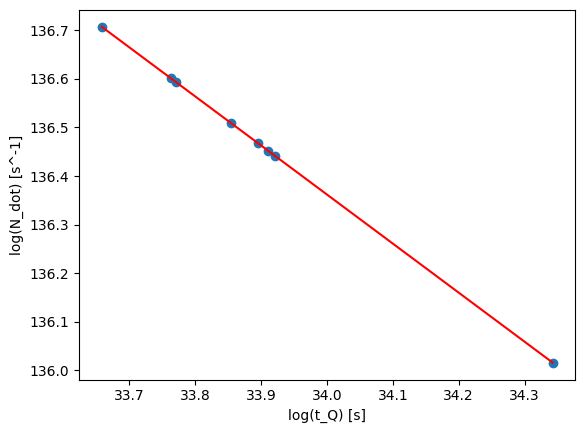

In [4]:
# Curve fitting to find alpha and c such that N_dot = c * (t_Q)**(alpha)

# Using the log scale for fitting
def func(logt_Q, logc, alpha):
    return logc - alpha * logt_Q

popt, pcov = cft(func, np.log(t_Q), np.log(N_dot))
perr = np.sqrt(np.diag(pcov))

print("c =", np.exp(popt[0]), "+/-", np.exp(popt[0]) * perr[0])
print("alpha =", popt[1], "+/-", perr[1])

# Plotting the data points along with the fitted curve
plt.scatter(np.log(t_Q), np.log(N_dot), label='Data Points')
plt.plot(np.log(t_Q), func(np.log(t_Q), popt[0], popt[1]), color='red', label='Fitted Curve')
plt.xlabel('log(t_Q) [s]')
plt.ylabel('log(N_dot) [s^-1]')


In [5]:
N_dot * (t_Q)**(1.0018794667876192)

array([1.03637628e+74, 1.03799042e+74, 1.03690990e+74, 1.03705568e+74,
       1.03661516e+74, 1.03623373e+74, 1.03494586e+74, 1.03207451e+74])

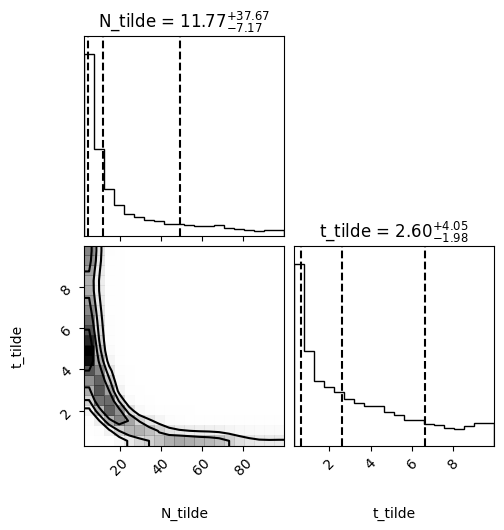

In [6]:
fig = corner.corner(samples, labels=["N_tilde", "t_tilde"],  quantiles=[0.16, 0.5, 0.84], show_titles=True, plot_datapoints=True, smooth=1)
plt.plot()
plt.show()